
User input secret string :  1101

Number of bits :  4
We now crteate a mapping f:{0,1}^n --> {0,1}^n such that 
f(x) = f(x xor secret_string) from user input for x belongs to {0,1}^n

Final Mapping:

f(0000) = f(1101) = 0001
f(0001) = f(1100) = 1000
f(0010) = f(1111) = 1101
f(0011) = f(1110) = 1100
f(0100) = f(1001) = 1001
f(0101) = f(1000) = 0000
f(0110) = f(1011) = 0011
f(0111) = f(1010) = 0101
f(1000) = f(0101) = 0000
f(1001) = f(0100) = 1001
f(1010) = f(0111) = 0101
f(1011) = f(0110) = 0011
f(1100) = f(0001) = 1000
f(1101) = f(0000) = 0001
f(1110) = f(0011) = 1100
f(1111) = f(0010) = 1101


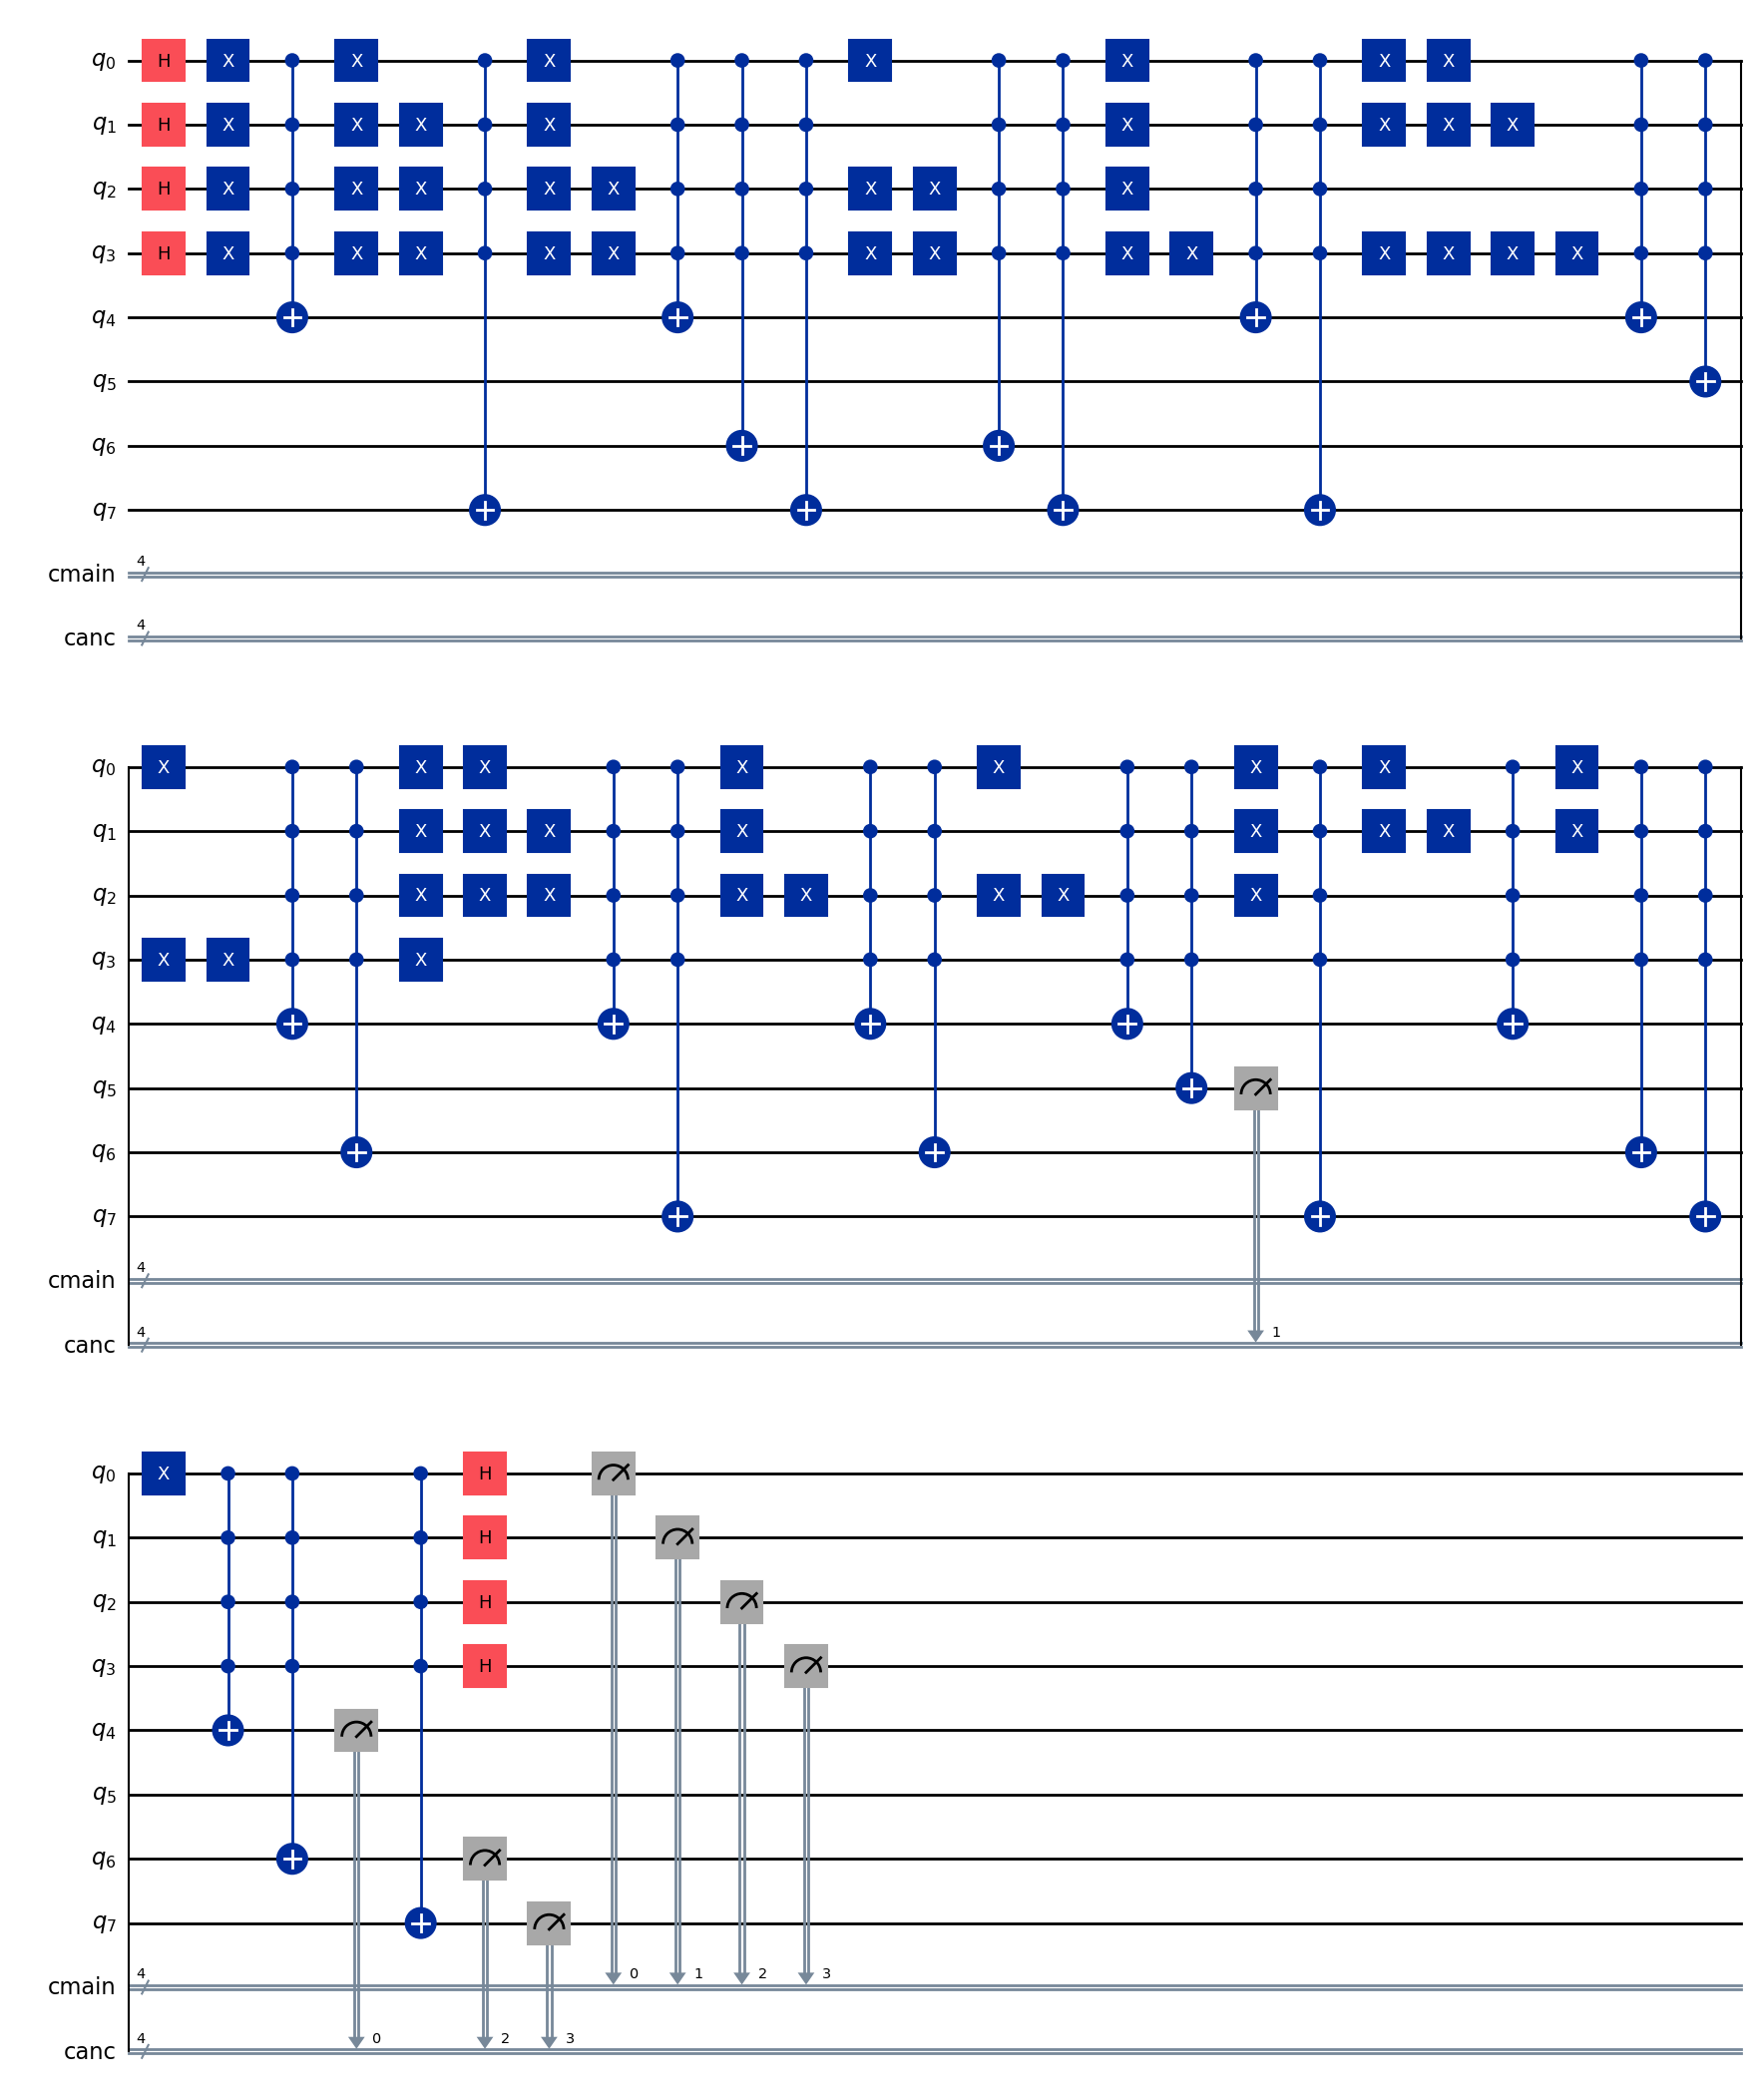

Measured y: 1011
Accepted


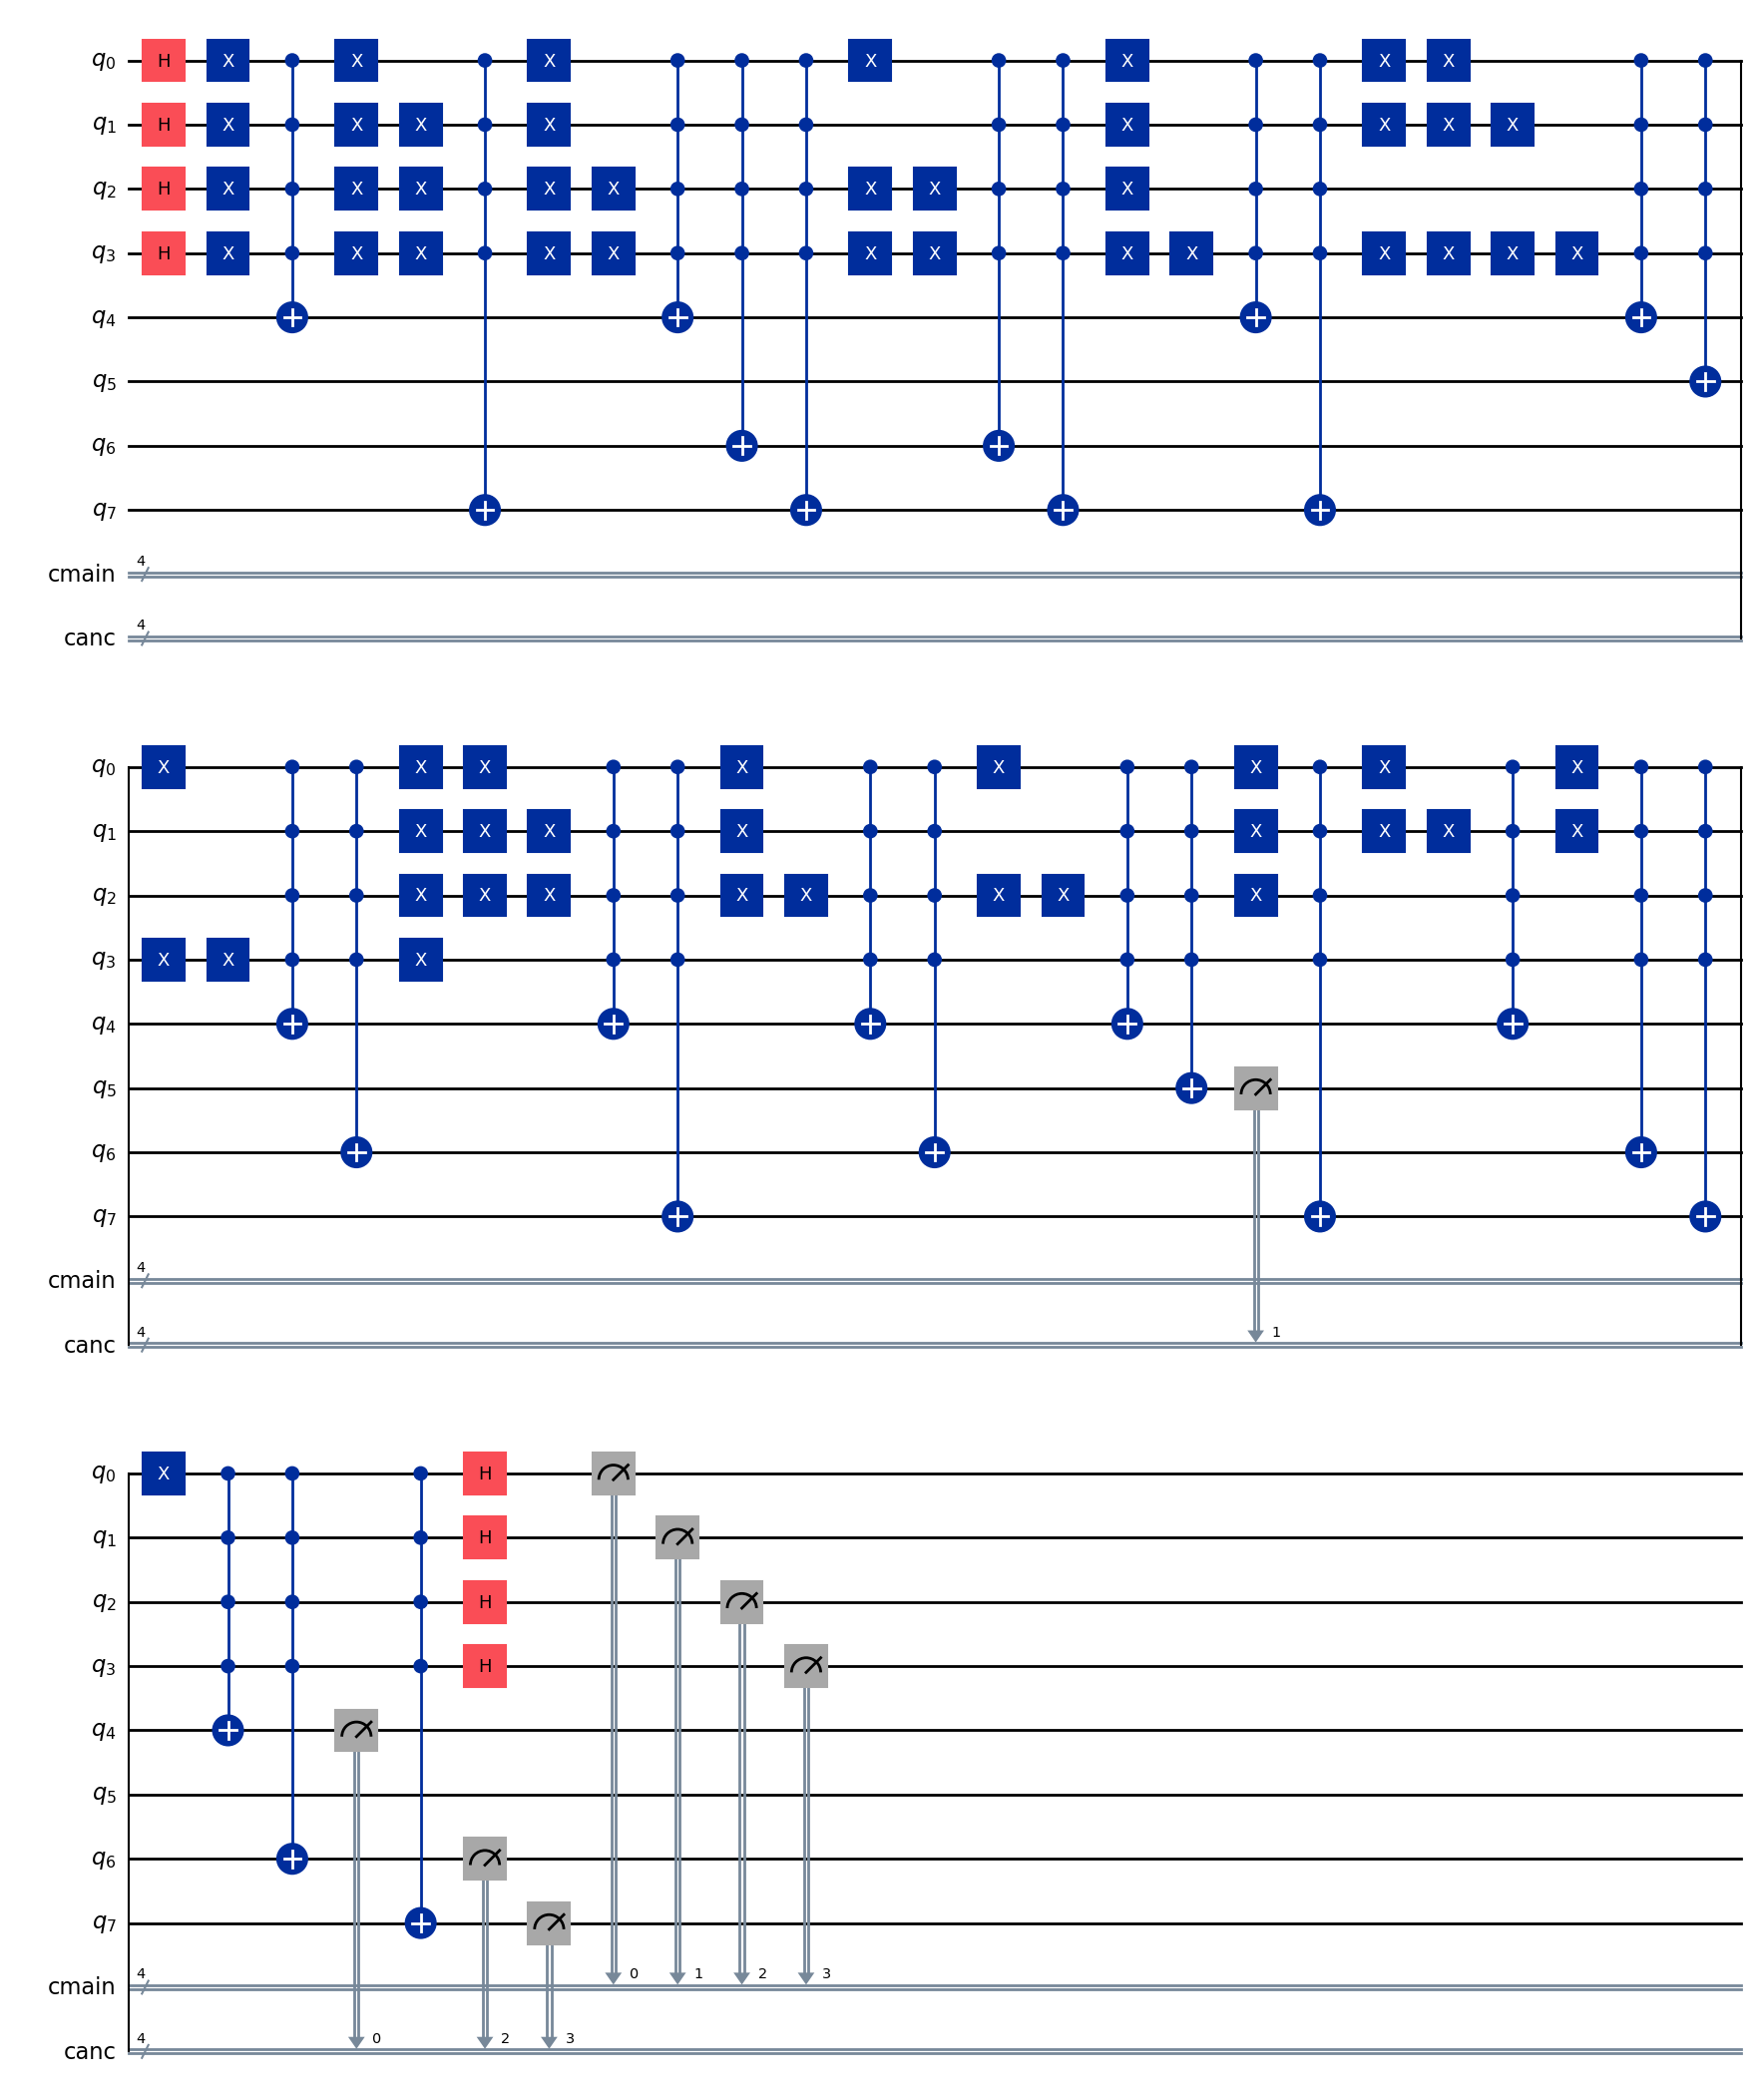

Measured y: 1110
Accepted


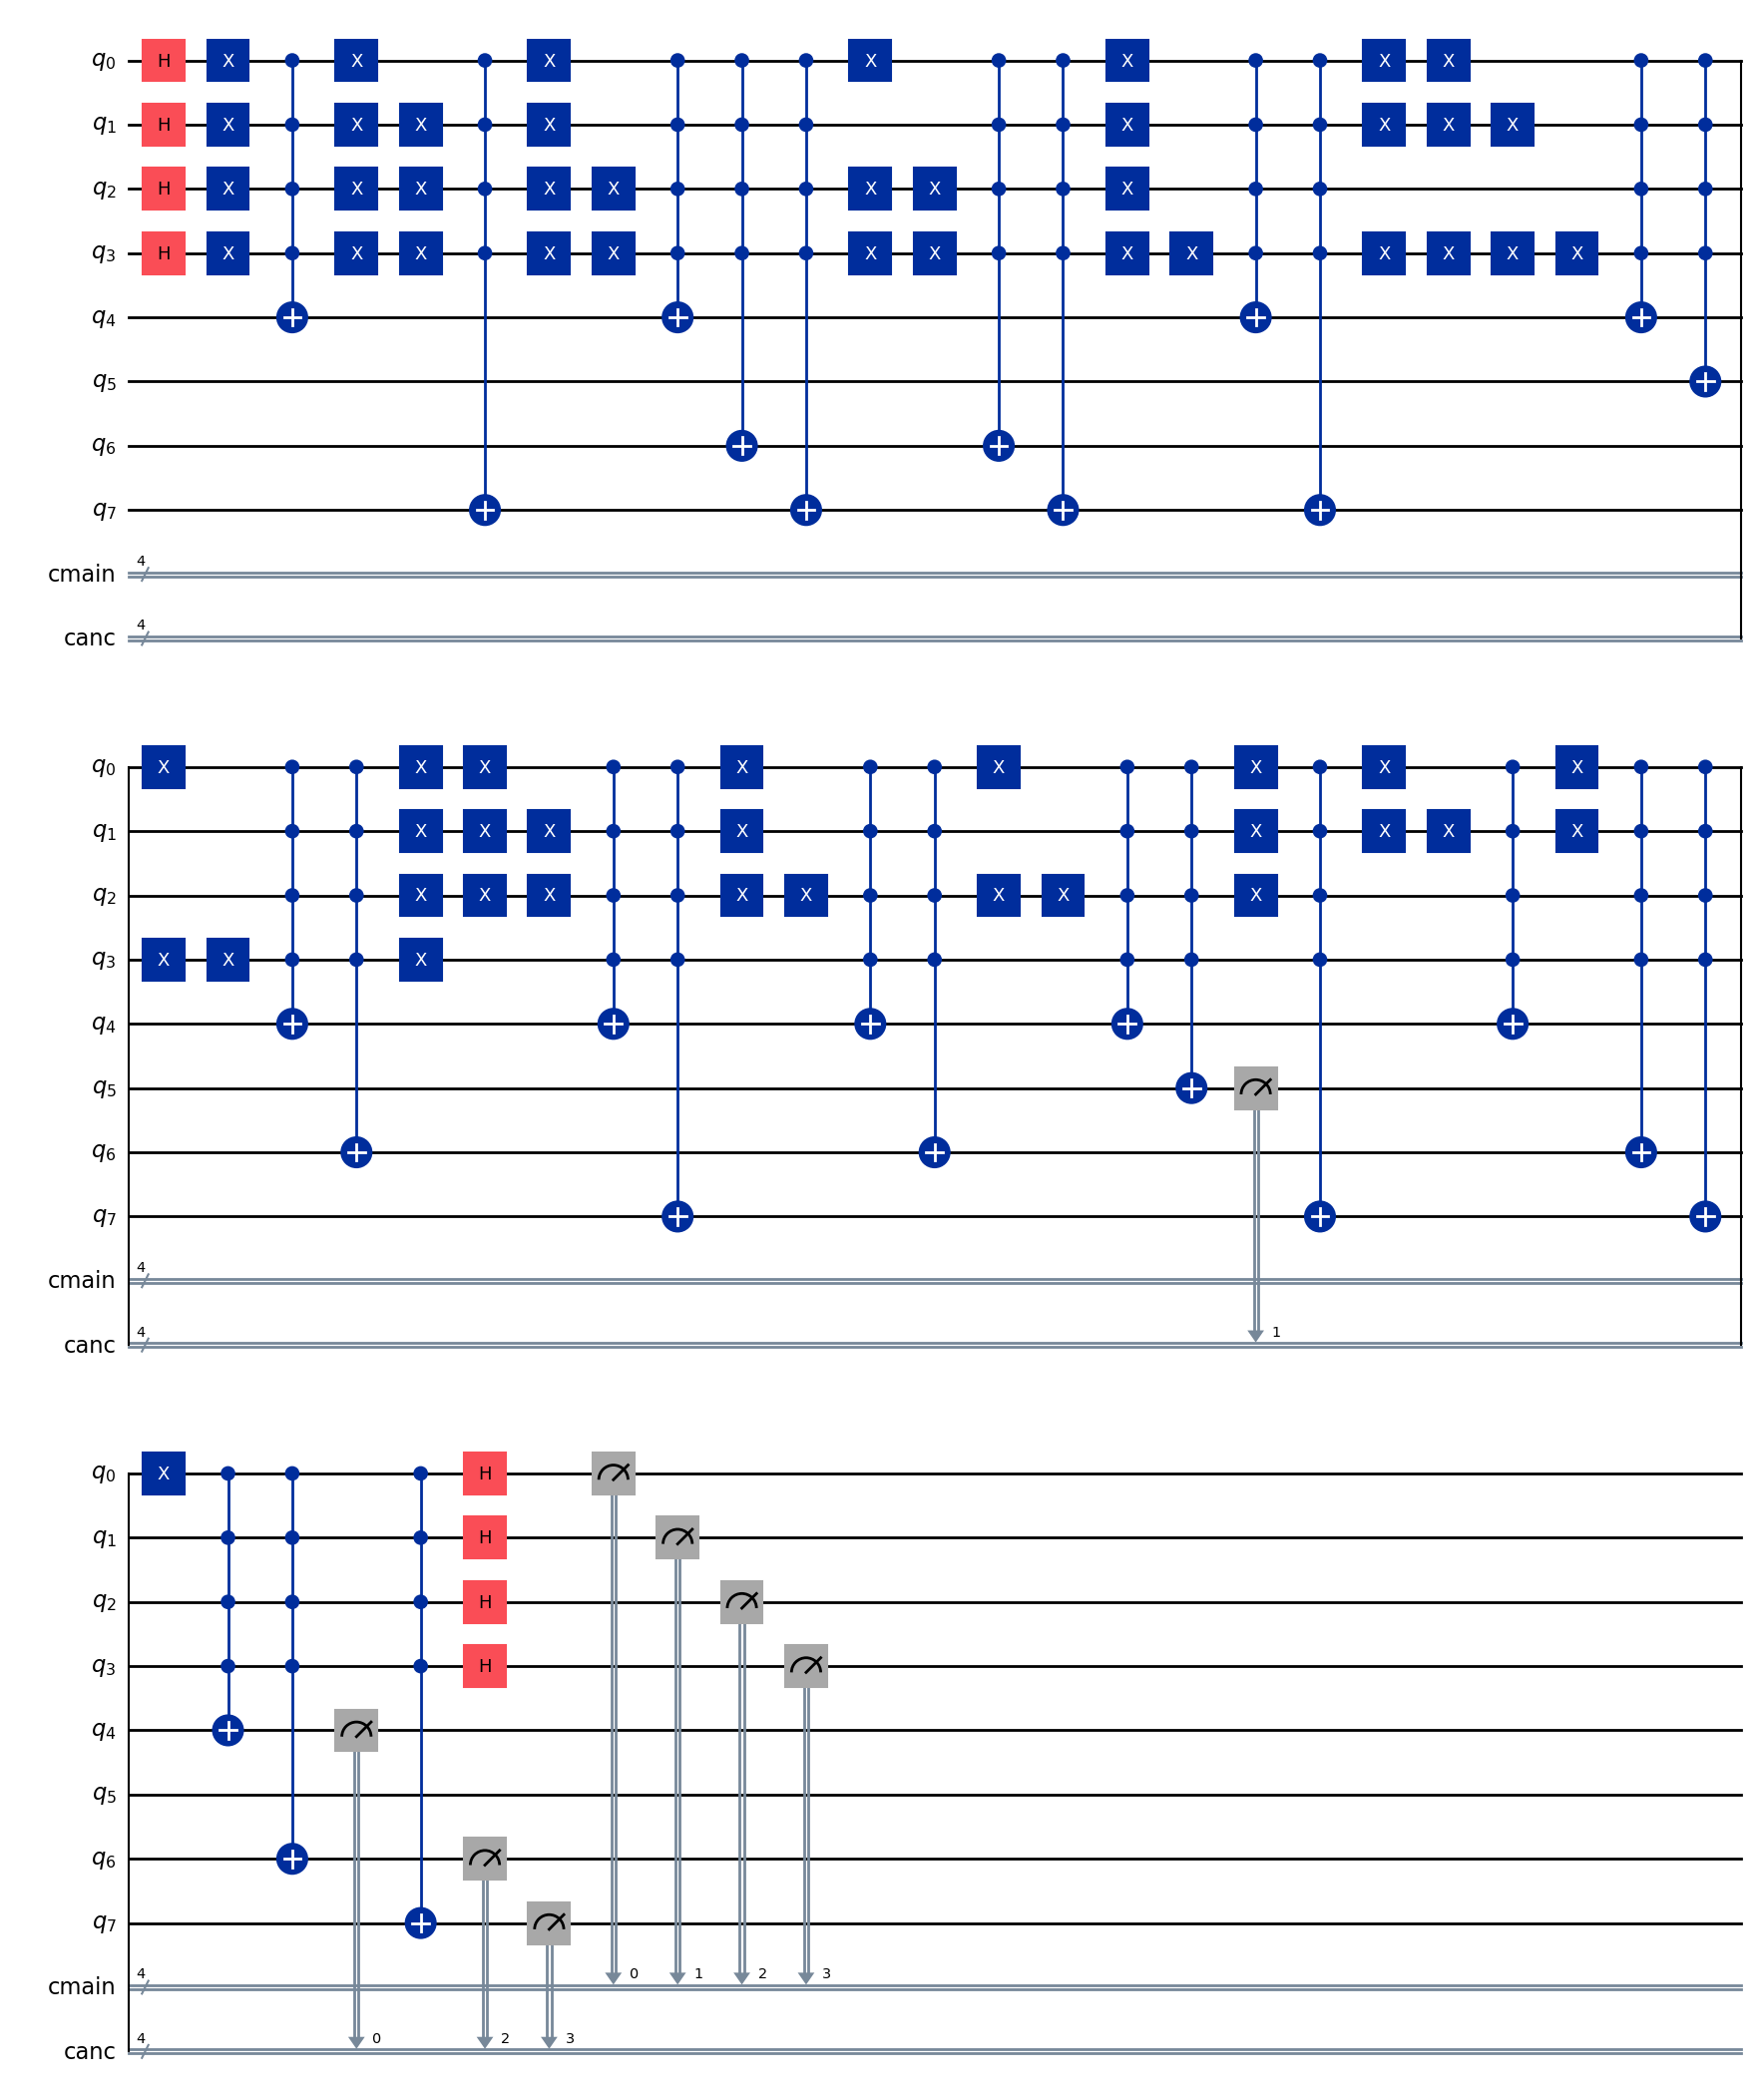

Measured y: 0000
Rejected zero vector


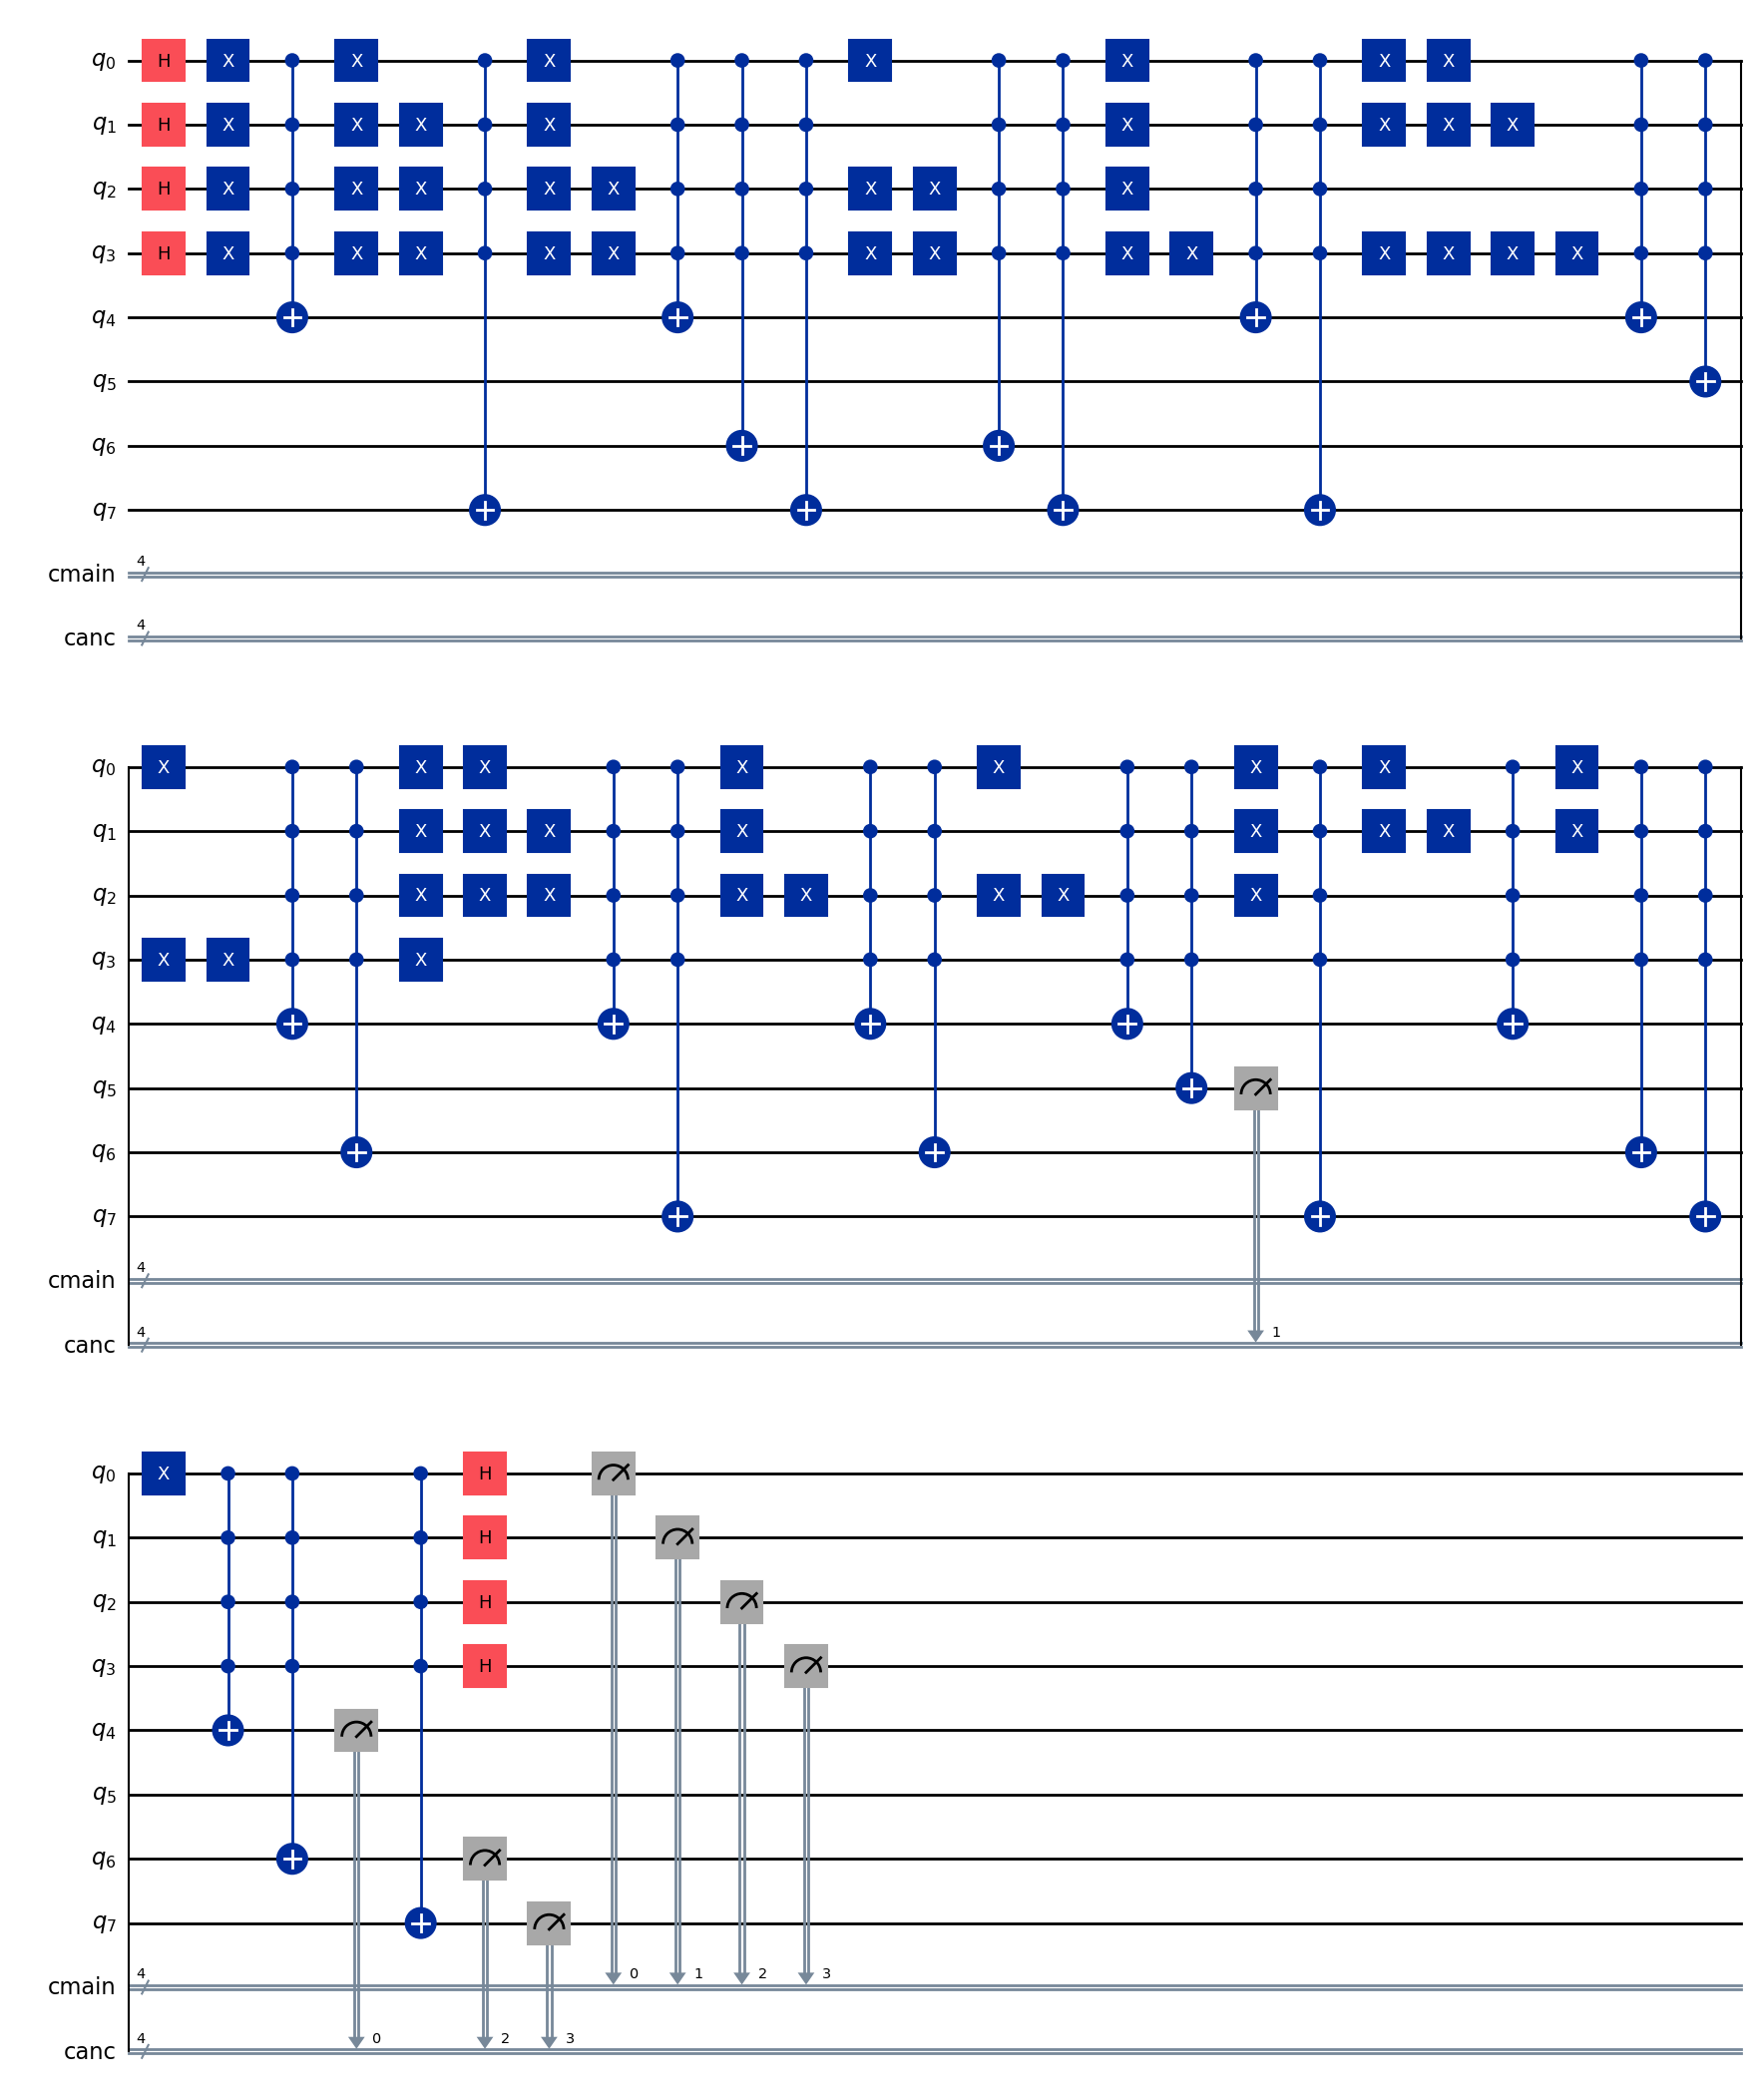

Measured y: 0101
Rejected dependent vector


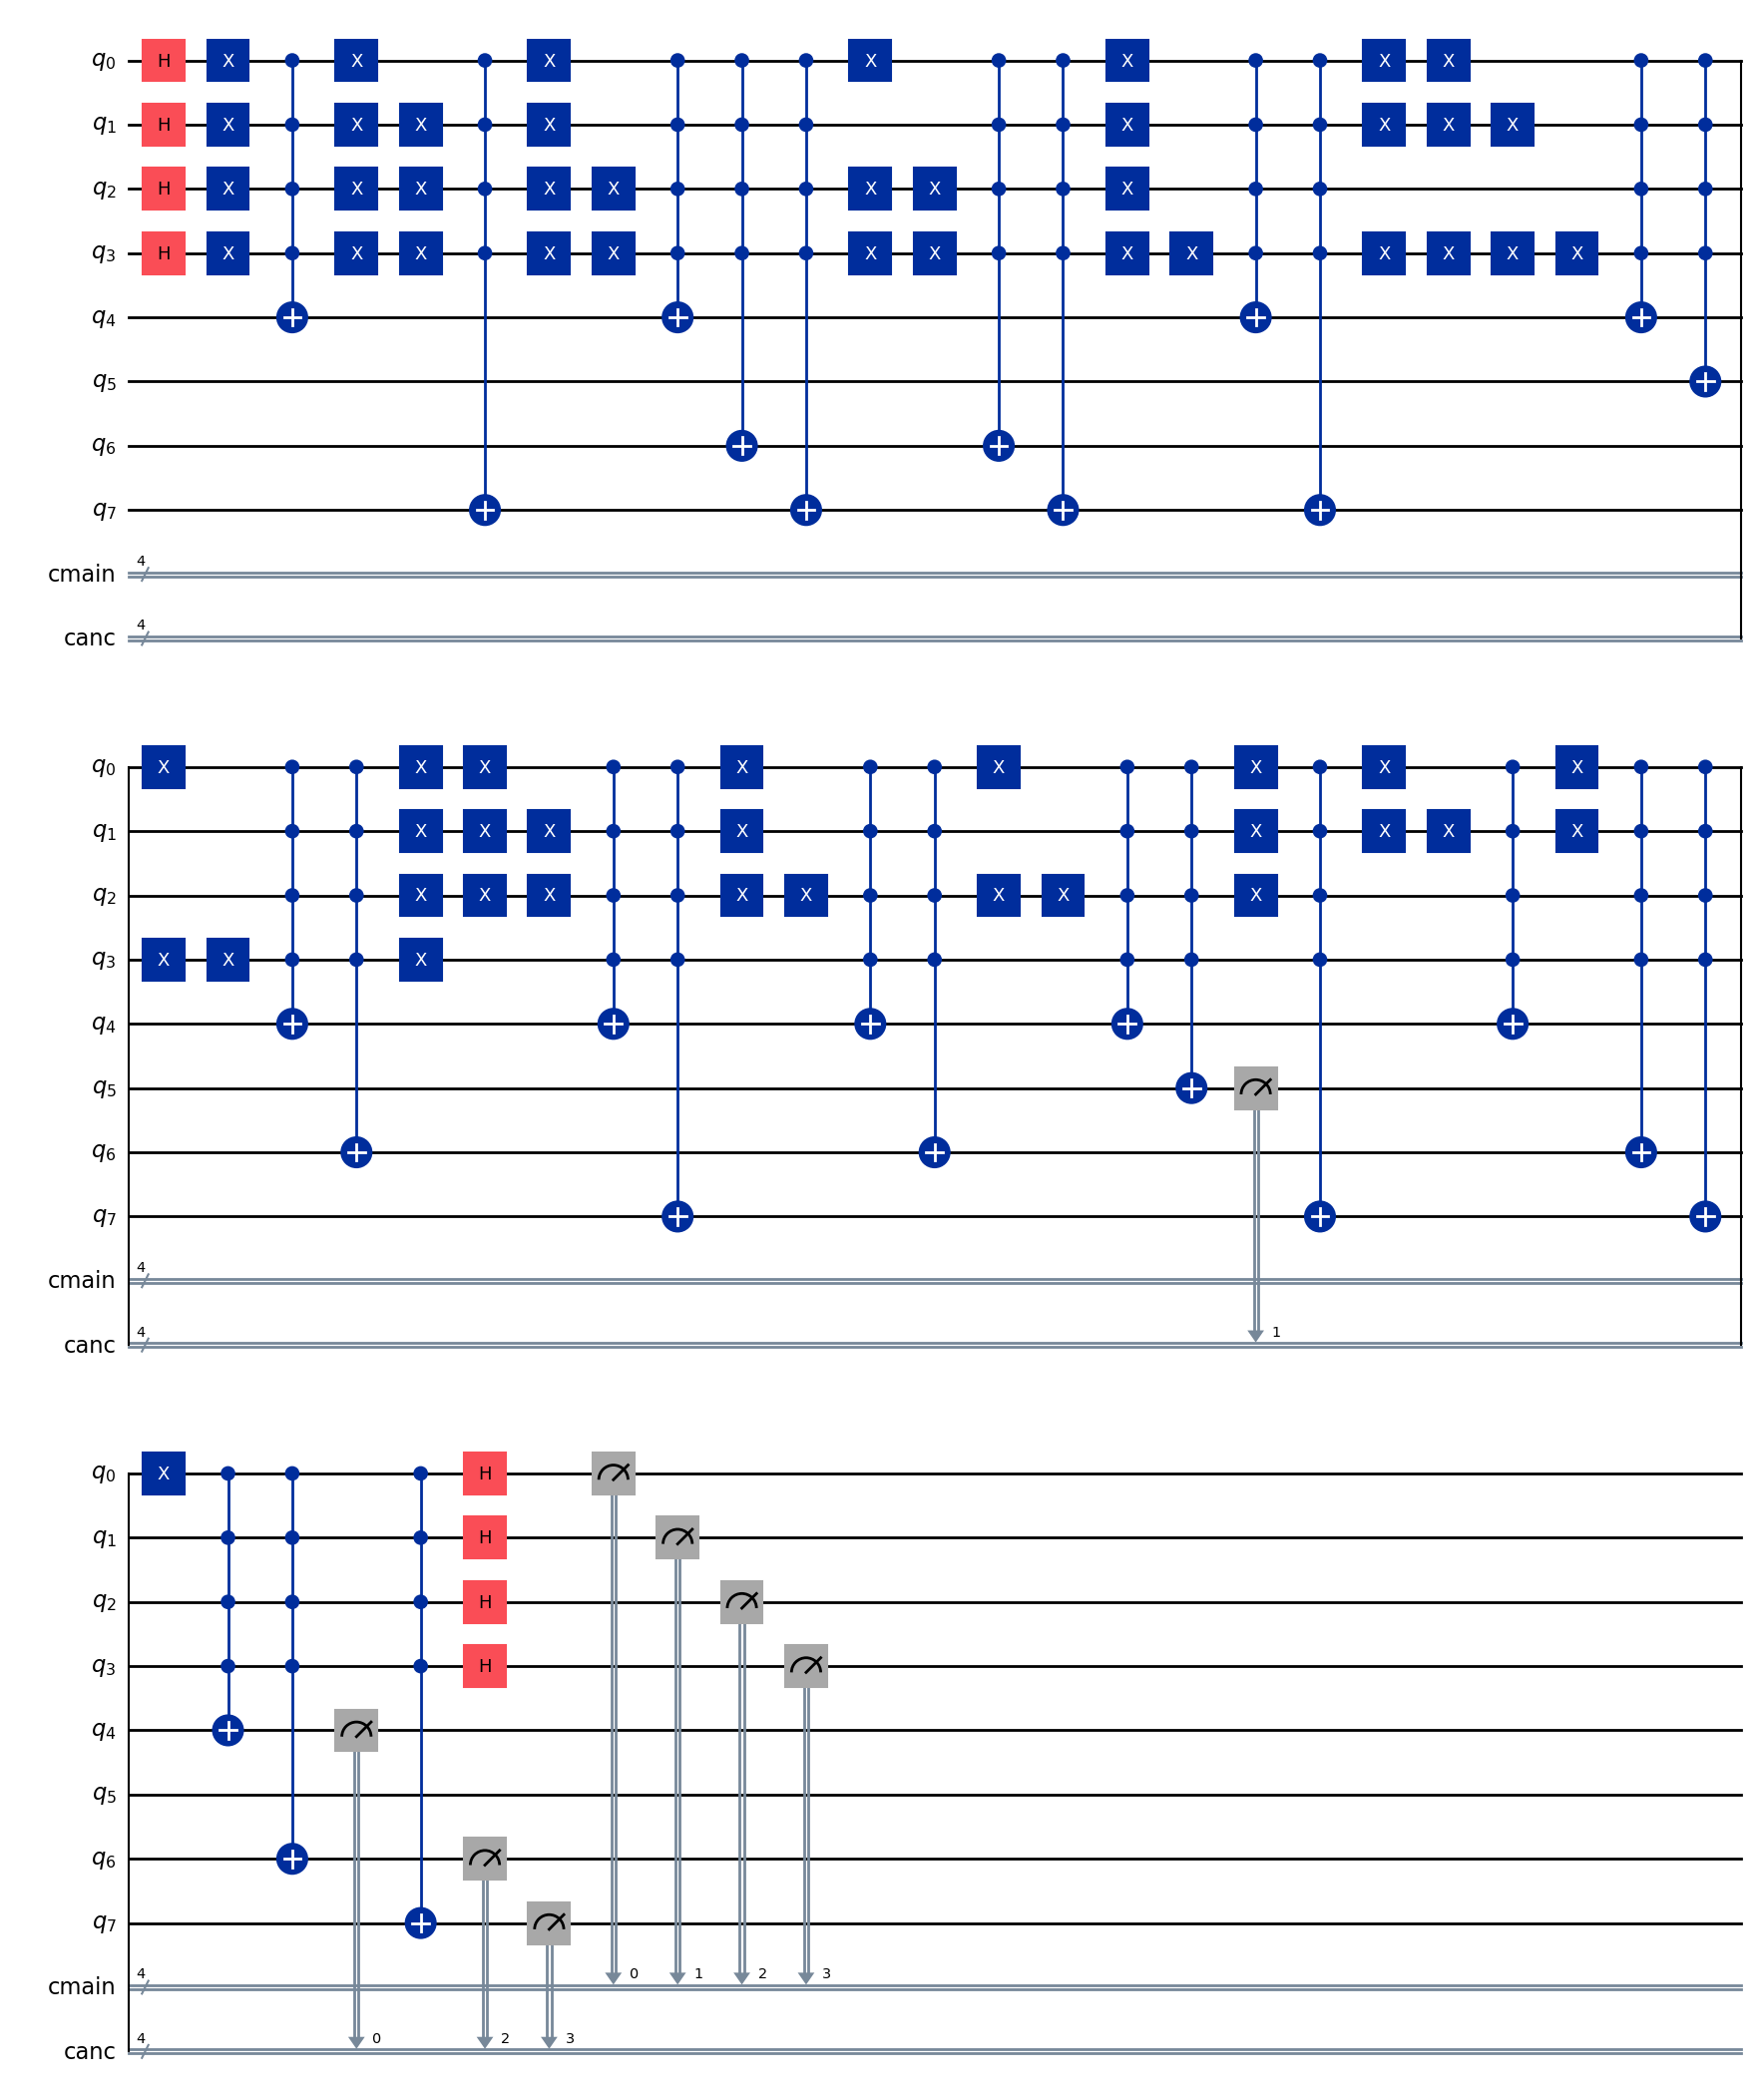

Measured y: 0111
Accepted

Y matrix:
['1', '0', '1', '1']
['1', '1', '1', '0']
['0', '1', '1', '1']

Recovered secret string s: 1101
Original secret string s : 1101


In [ ]:
from qiskit import QuantumRegister, QuantumCircuit, ClassicalRegister
from qiskit.quantum_info import *
from qiskit . visualization import plot_histogram
from numpy import sqrt
from IPython.display import Math, display
from qiskit.circuit.library import UnitaryGate
from numpy import pi, cos, sin, exp
from qiskit_aer import AerSimulator
from qiskit_aer.library import save_statevector
import random
import numpy as np 

bits_no = int(input("Enter the number of bits"))
secret_string = list(str(input("Enter your secret string")))

print("\nUser input secret string : ", ''.join(secret_string))
print("\nNumber of bits : ", bits_no)

# Making the mapping

print("We now crteate a mapping f:{0,1}^n --> {0,1}^n such that \nf(x) = f(x xor secret_string) from user input for x belongs to {0,1}^n")

N = 2**bits_no

all_inputs = []

for i in range(N):
    all_inputs.append(format(i, f"0{bits_no}b"))

visited = set()

mapping = {}

for x in all_inputs:

    if x in visited:
        continue

    s_int = int(''.join(secret_string), 2)

    pair = format(int(x, 2) ^ s_int, f"0{bits_no}b")

    output_value = input(f"Enter common output for f({x}) and f({pair}) : ")

    mapping[x] = output_value
    mapping[pair] = output_value

    visited.add(x)
    visited.add(pair)

print("\nFinal Mapping:\n")

for x in all_inputs:

    s_int = int(''.join(secret_string), 2)

    pair = format(int(x, 2) ^ s_int, f"0{bits_no}b")

    print(f"f({x}) = f({pair}) = {mapping[x]}")


# Function for a dot product

def dot_mod2(a, b):
    total = 0
    for i in range(len(a)):
        total += int(a[i]) * int(b[i])
    return total % 2

# Function for finding rank

def rank_mod2(matrix):

    if len(matrix) == 0:
        return 0

    A = np.array(matrix, dtype=int) % 2

    rows, cols = A.shape

    rank = 0

    for col in range(cols):

        pivot = None

        for r in range(rank, rows):

            if A[r, col] == 1:
                pivot = r
                break

        if pivot is None:
            continue

        A[[rank, pivot]] = A[[pivot, rank]]

        for r in range(rows):

            if r != rank and A[r, col] == 1:
                A[r] = (A[r] + A[rank]) % 2

        rank += 1

    return rank

# Function for finding the Null vector of a matrix 

def find_null_vector_mod2(Y, bits_no):

    A = np.array(Y, dtype=int) % 2
    rows, cols = A.shape

    pivot_cols = []
    rank = 0

    # Row reduce A over mod 2
    for col in range(cols):

        pivot = None

        for r in range(rank, rows):
            if A[r, col] == 1:
                pivot = r
                break

        if pivot is None:
            continue

        A[[rank, pivot]] = A[[pivot, rank]]

        for r in range(rows):
            if r != rank and A[r, col] == 1:
                A[r] = (A[r] + A[rank]) % 2

        pivot_cols.append(col)
        rank += 1

    # Find free column
    free_cols = []

    for col in range(cols):
        if col not in pivot_cols:
            free_cols.append(col)

    # Since Simon gives n-1 independent equations,
    # nullspace dimension should be 1
    free_col = free_cols[0]

    s = np.zeros(cols, dtype=int)

    # Set free variable = 1
    s[free_col] = 1

    # Back substitute
    for i in reversed(range(rank)):

        pivot_col = pivot_cols[i]

        total = 0

        for j in range(pivot_col + 1, cols):
            total = (total + A[i, j] * s[j]) % 2

        s[pivot_col] = total

    return ''.join(str(bit) for bit in s)

Y_matrix = []

while len(Y_matrix) < bits_no - 1:

    # Create fresh circuit each run
    q_reg = QuantumRegister(2 * bits_no, "q")
    c_main = ClassicalRegister(bits_no, "cmain")
    c_anc = ClassicalRegister(bits_no, "canc")

    circuit_1 = QuantumCircuit(q_reg, c_main, c_anc)

    # Hadamard on first register
    for i in range(bits_no):
        circuit_1.h(i)

    # Oracle
    for x in all_inputs:

        output_value = mapping[x]

        for i, bit in enumerate(reversed(x)):
            if bit == '0':
                circuit_1.x(i)

        for j, bit in enumerate(reversed(output_value)):
            if bit == '1':
                circuit_1.mcx(list(range(bits_no)), bits_no + j)

        for i, bit in enumerate(reversed(x)):
            if bit == '0':
                circuit_1.x(i)

    # Measure ancilla/output register
    circuit_1.measure(
        list(range(bits_no, 2 * bits_no)),
        c_anc
    )

    # Hadamard again on main register
    for i in range(bits_no):
        circuit_1.h(i)

    # Measure main register
    circuit_1.measure(
        list(range(bits_no)),
        c_main
    )

    display(circuit_1.draw(output="mpl"))

    sim = AerSimulator()
    result = sim.run(circuit_1, shots=1).result()
    counts = result.get_counts()

    output_string = list(counts.keys())[0]

    # counts has format like: 'ancilla main'
    main_y = output_string.split(" ")[-1]

    print("Measured y:", main_y)

    if main_y == "0" * bits_no:
        print("Rejected zero vector")
        continue

    temp_matrix = Y_matrix + [list(main_y)]

    if rank_mod2(temp_matrix) > rank_mod2(Y_matrix):
        Y_matrix.append(list(main_y))
        print("Accepted")
    else:
        print("Rejected dependent vector")


print("\nY matrix:")
for row in Y_matrix:
    print(row)

recovered_s = find_null_vector_mod2(Y_matrix, bits_no)

print("\nRecovered secret string s:", recovered_s)
print("Original secret string s :", ''.join(secret_string))



